# Modeling Errors in Transient ISE
Modeling errors are a common problem in ISE because the (modeled or measured) FRFs will rarely match exact structural dynamics contained within the responses due to nonlinearities, measurement/modeling errors, etc. This notebook will demonstrate how these modeling errors can induce apparent non-causalities in the ISE problem by using FRFs from the [perturbed beam system](sec:perturbed_beam_system) to estimate the high frequency pulse.

In [1]:
import sdynpy as sdpy
import numpy as np
from scipy.fft import irfft
from forcefinder.core.transient_utilities import frequency_interpolation
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':10,
                     'font.family':'Times New Roman'})

In [2]:
truth_pulse = sdpy.TimeHistoryArray.load(r'system_data/high_freq_truth_pulse_excitation.npz')
truth_response = sdpy.TimeHistoryArray.load(r'system_data/high_freq_truth_response.npz')
perturbed_beam_system = sdpy.System.load(r'system_data/perturbed_beam_system.npz')

The FRFs in this notebook will be computed using the full 0-5,000 Hz frequency range, which [was shown](noncausal_frfs.ipynb) to generate FRFs that are approximately causal. 

In [3]:
Fs = 10000
T = 1 # seconds
frequency = np.arange(stop=Fs/2+1/T, step=1/T)

## ISE Using Truth Excitation DOFs
First the ISE problem will be performed using the set-up that was described in the [introduction](causality_study_introduction.ipynb). Like the other notebooks, the FRFs are being computed from the `System` object using the `frequency_response` method. 

In [ ]:
response_coordinate = sdpy.coordinate_array(node=[102,104,106,108], direction=3)
reference_coordinate = sdpy.coordinate_array(string_array=['103Z+', '104Z+'])

perturbed_frfs = perturbed_beam_system.frequency_response(frequency, responses=response_coordinate, 
                                         references=reference_coordinate, displacement_derivative=2)

The responses are prepared for the upcoming ISE operations by zero padding to mitigate [circular convolution errors](circular_convolution.ipynb), then converting to the frequency domain. 

In [5]:
model_order = perturbed_frfs.ifft().num_elements
padded_response = truth_response.zero_pad(2*model_order, left=True, right = True,
                                          use_next_fast_len=False)
padded_response_fft = padded_response.fft(norm='backward')
padded_response_fft_ord = np.moveaxis(padded_response_fft.ordinate,-1,0)[...,np.newaxis]

The FRFs are being interpolated in the frequency domain, which was [previously identified](zero_padding.ipynb) as a best practice (for this problem set-up). 

In [6]:
perturbed_frfs_zero_padded = frequency_interpolation(perturbed_frfs[0,0].abscissa, 
                                                     np.moveaxis(perturbed_frfs.ordinate,-1,0),
                                                     padded_response.num_elements, 
                                                     padded_response.abscissa_spacing)

estimated_pulse_fft_perturbed = np.linalg.pinv(perturbed_frfs_zero_padded)@padded_response_fft_ord
estimated_pulse_perturbed = irfft(estimated_pulse_fft_perturbed, n=padded_response.num_elements, 
                                  axis=0, norm='backward')

The plots below show the estimated forces for the full time range and for a zoomed in time range that is immediately around the truth pulse for a given DOF. Four different errors can be seen in these plots:

1. The estimated pulses do not have the correct amplitude
2. There is significant ringing in the estimated forces, which does not exist in the truth pulses
3. Energy is spread between both force DOFs rather than a single pulse per DOF
4. There is pre-ringing in the estimated forces before there is any energy in the truth response or truth pulse

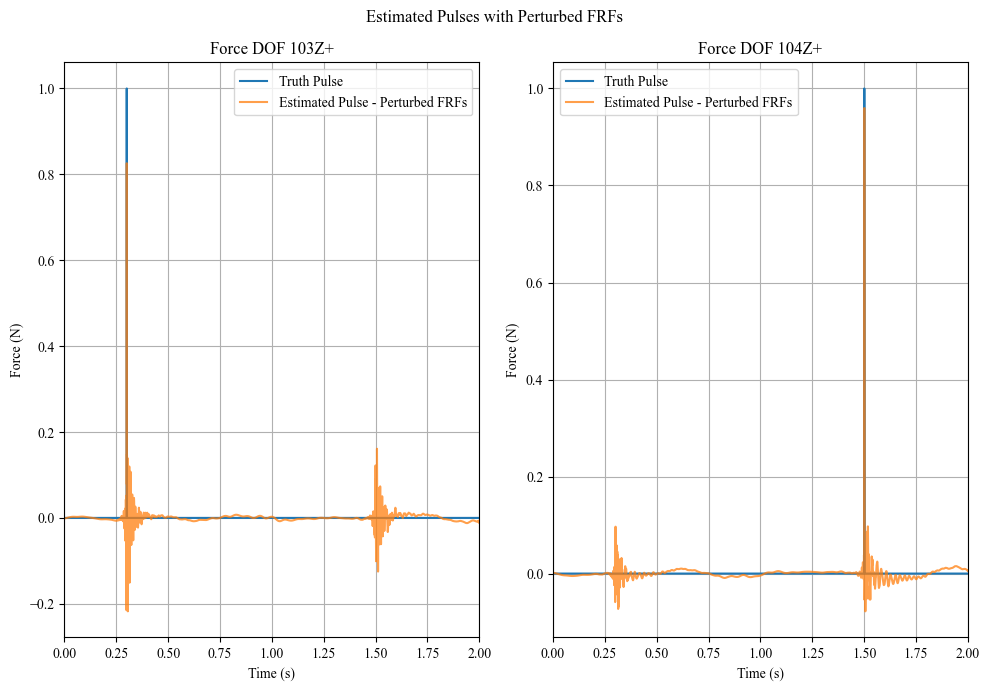

In [20]:
fig, ax = plt.subplots(1,2, figsize=(10,7))
time_ranges = [(0,2), (0,2)]

for ii in range(2):
    ax[ii].plot(truth_pulse[ii].abscissa, truth_pulse[ii].ordinate, label='Truth Pulse')
    ax[ii].plot(padded_response[0].abscissa, estimated_pulse_perturbed[:,ii,:], 
                    label='Estimated Pulse - Perturbed FRFs', alpha=0.75)
    ax[ii].set_xlim(left=time_ranges[ii][0], right=time_ranges[ii][1])
    ax[ii].grid(); ax[ii].set_xlabel('Time (s)'); ax[ii].set_ylabel('Force (N)') 
    ax[ii].set_title('Force DOF {:}'.format(truth_pulse[ii].response_coordinate.string_array()));
    ax[ii].legend()

fig.suptitle('Estimated Pulses with Perturbed FRFs')
fig.tight_layout()

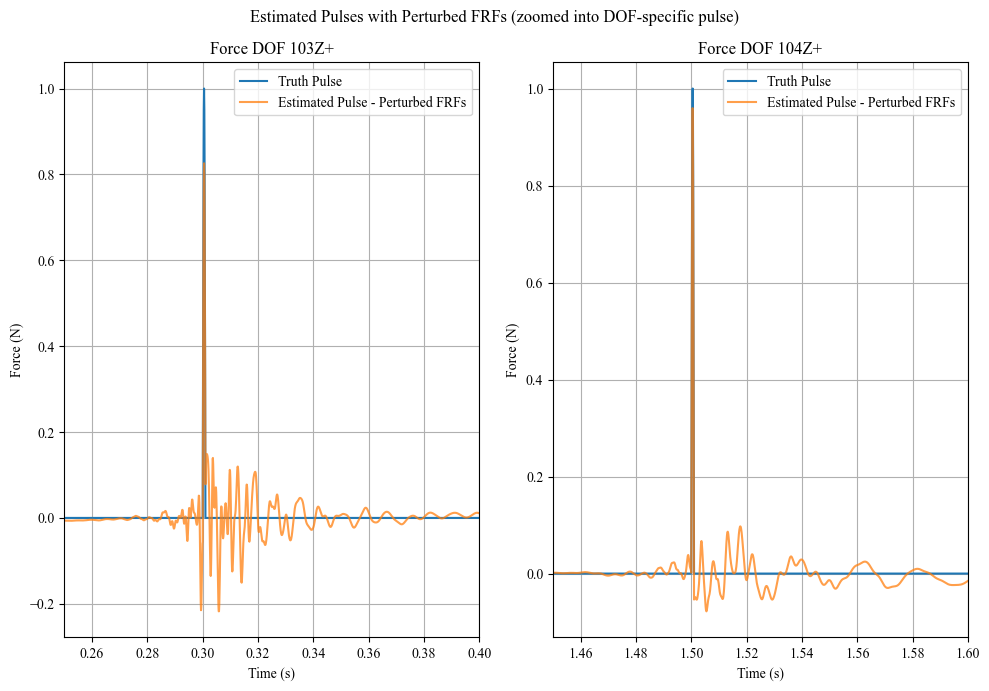

In [21]:
fig, ax = plt.subplots(1,2, figsize=(10,7))
time_ranges = [(0.25,0.4), (1.45,1.6)]

for ii in range(2):
    ax[ii].plot(truth_pulse[ii].abscissa, truth_pulse[ii].ordinate, label='Truth Pulse')
    ax[ii].plot(padded_response[0].abscissa, estimated_pulse_perturbed[:,ii,:], 
                    label='Estimated Pulse - Perturbed FRFs', alpha=0.75)
    ax[ii].set_xlim(left=time_ranges[ii][0], right=time_ranges[ii][1])
    ax[ii].grid(); ax[ii].set_xlabel('Time (s)'); ax[ii].set_ylabel('Force (N)') 
    ax[ii].set_title('Force DOF {:}'.format(truth_pulse[ii].response_coordinate.string_array()));
    ax[ii].legend()

fig.suptitle('Estimated Pulses with Perturbed FRFs (zoomed into DOF-specific pulse)')
fig.tight_layout()

Interestingly, the pre-ringing from the estimated forces can also be seen in the reconstructed responses (from the estimated forces). This error is shown in the plots below, which are zoomed into the time ranges for the responses to the first and second pulses. In addition to the pre-ringing, there are significant errors in the reconstructed response throughout the whole time range.

```{note}
The reconstructed responses were computed by multiplying the estimated forces by the FRFs in the frequency domain rather than using a convolution process in the time domain. 
```

In [9]:
reconstructed_response_response_perturbed = perturbed_frfs_zero_padded@estimated_pulse_fft_perturbed
reconstructed_response_response_perturbed_time = irfft(reconstructed_response_response_perturbed, 
                                                       n=padded_response.num_elements, 
                                                       axis=0, norm='backward')

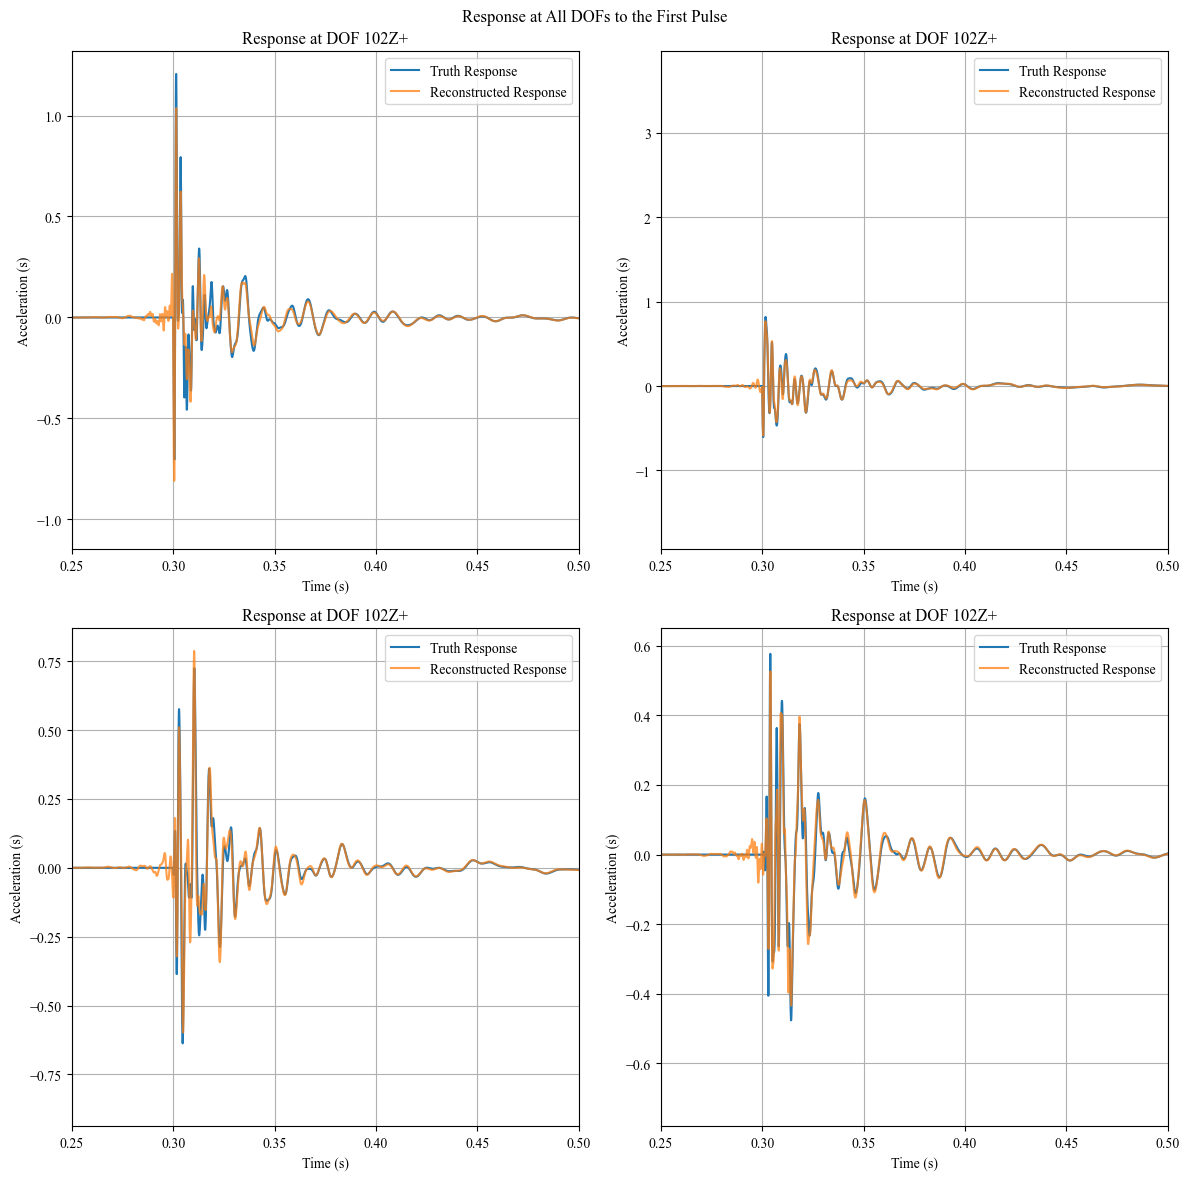

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(12,12))

for ii in range(2):
    for jj in range(2): 
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, padded_response[ii*2+jj].ordinate, 
                       label='Truth Response')
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, 
                       reconstructed_response_response_perturbed_time[:,ii*2+jj,0],
                       label='Reconstructed Response', alpha=0.75)
        ax[ii,jj].grid(); ax[ii,jj].legend(); ax[ii,jj].set_xlim(left=0.25, right=0.5)
        ax[ii,jj].set_xlabel('Time (s)'); ax[ii,jj].set_ylabel('Acceleration (m/s$^2$)')
        ax[ii,jj].set_title('Response at DOF {:}'.format(padded_response[ii*2+jj].response_coordinate.string_array()))

fig.suptitle('Response at All DOFs to the First Pulse')
fig.tight_layout()

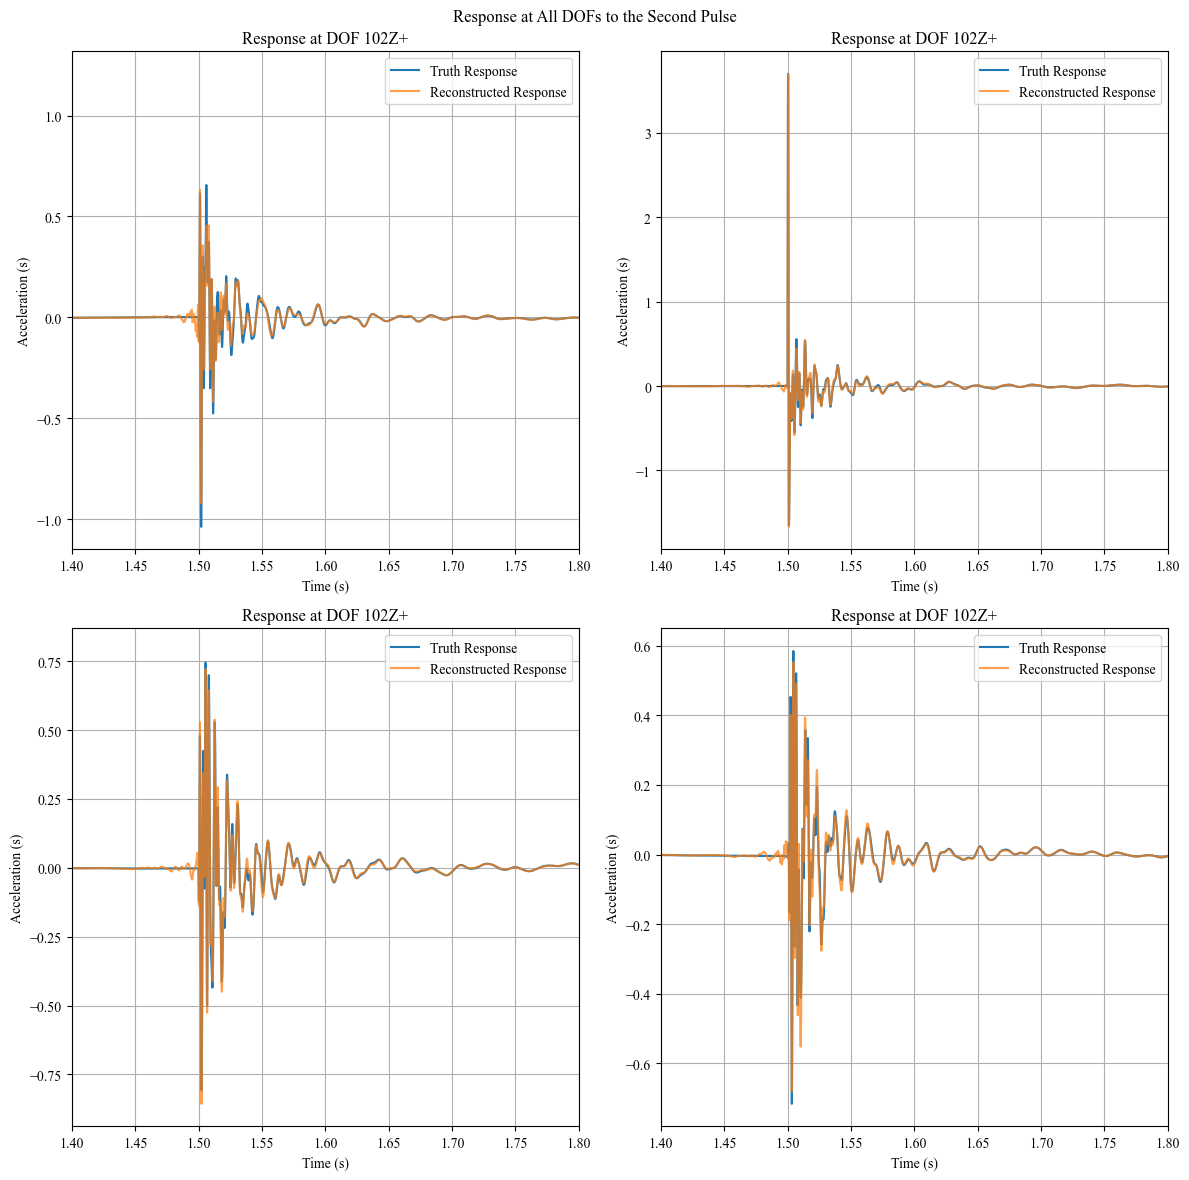

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(12,12))

for ii in range(2):
    for jj in range(2): 
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, padded_response[ii*2+jj].ordinate, label='Truth Response')
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, reconstructed_response_response_perturbed_time[:,ii*2+jj,0],
                    label='Reconstructed Response', alpha=0.75)
        ax[ii,jj].grid(); ax[ii,jj].legend(); ax[ii,jj].set_xlim(left=1.4, right=1.8)
        ax[ii,jj].set_xlabel('Time (s)'); ax[ii,jj].set_ylabel('Acceleration (m/s$^2$)')
        ax[ii,jj].set_title('Response at DOF {:}'.format(padded_response[ii*2+jj].response_coordinate.string_array()))

fig.suptitle('Response at All DOFs to the Second Pulse')
fig.tight_layout()

## ISE Using Extra Excitation DOFs
The errors in the reconstructed responses that were shown above indicated that the ISE set-up with the truth excitation DOFs and perturbed system FRFs could not sufficiently control the motion of the beam. Consequently, extra excitation DOFs were added to the FRF matrix, as shown in the image below where the red arrows below the beam are the excitation DOFs. This ISE problem set-up is then used with the same code as the above ISE problem to estimate the forces and reconstruct the responses. 

```{note}
The variable names are the same for both ISE problem set-ups except the variables for the ISE problem with extra excitation DOFs are appended with at `_1`.
```

```{figure} images/beam_system_extra_excitation.svg
:alt: Beam System with Extra Excitation DOFs
:align: center
```

In [ ]:
reference_coordinate_1 = sdpy.coordinate_array(string_array=['103Z+', '104Z+', '105Z+', '106Z+'])

perturbed_frfs_1 = perturbed_beam_system.frequency_response(frequency, responses=response_coordinate, 
                                        references=reference_coordinate_1, displacement_derivative=2)

In [23]:
perturbed_frfs_zero_padded_1 = frequency_interpolation(perturbed_frfs_1[0,0].abscissa, 
                                                       np.moveaxis(perturbed_frfs_1.ordinate,-1,0),
                                                       padded_response.num_elements, 
                                                       padded_response.abscissa_spacing)

estimated_pulse_fft_perturbed_1 = np.linalg.pinv(perturbed_frfs_zero_padded_1)@padded_response_fft_ord
estimated_pulse_perturbed_1 = irfft(estimated_pulse_fft_perturbed_1, n=padded_response.num_elements, 
                                    axis=0, norm='backward')

In [24]:
reconstructed_response_response_perturbed_1 = perturbed_frfs_zero_padded_1@estimated_pulse_fft_perturbed_1
reconstructed_response_response_perturbed_time_1 = irfft(reconstructed_response_response_perturbed_1, 
                                                         n=padded_response.num_elements, 
                                                         axis=0, norm='backward')

The plots below show the estimated forces for all the DOFs with the time ranges zoomed into the times for the truth pulses, where the dashed black line indicates when the different truth pulses start. As expected, the estimated forces spread energy to all the force DOFs and include a significant amount of ringing during the response time. However, the estimated forces no longer show any pre-ringing before there is excitation or response energy in the system (for a given pulse). 

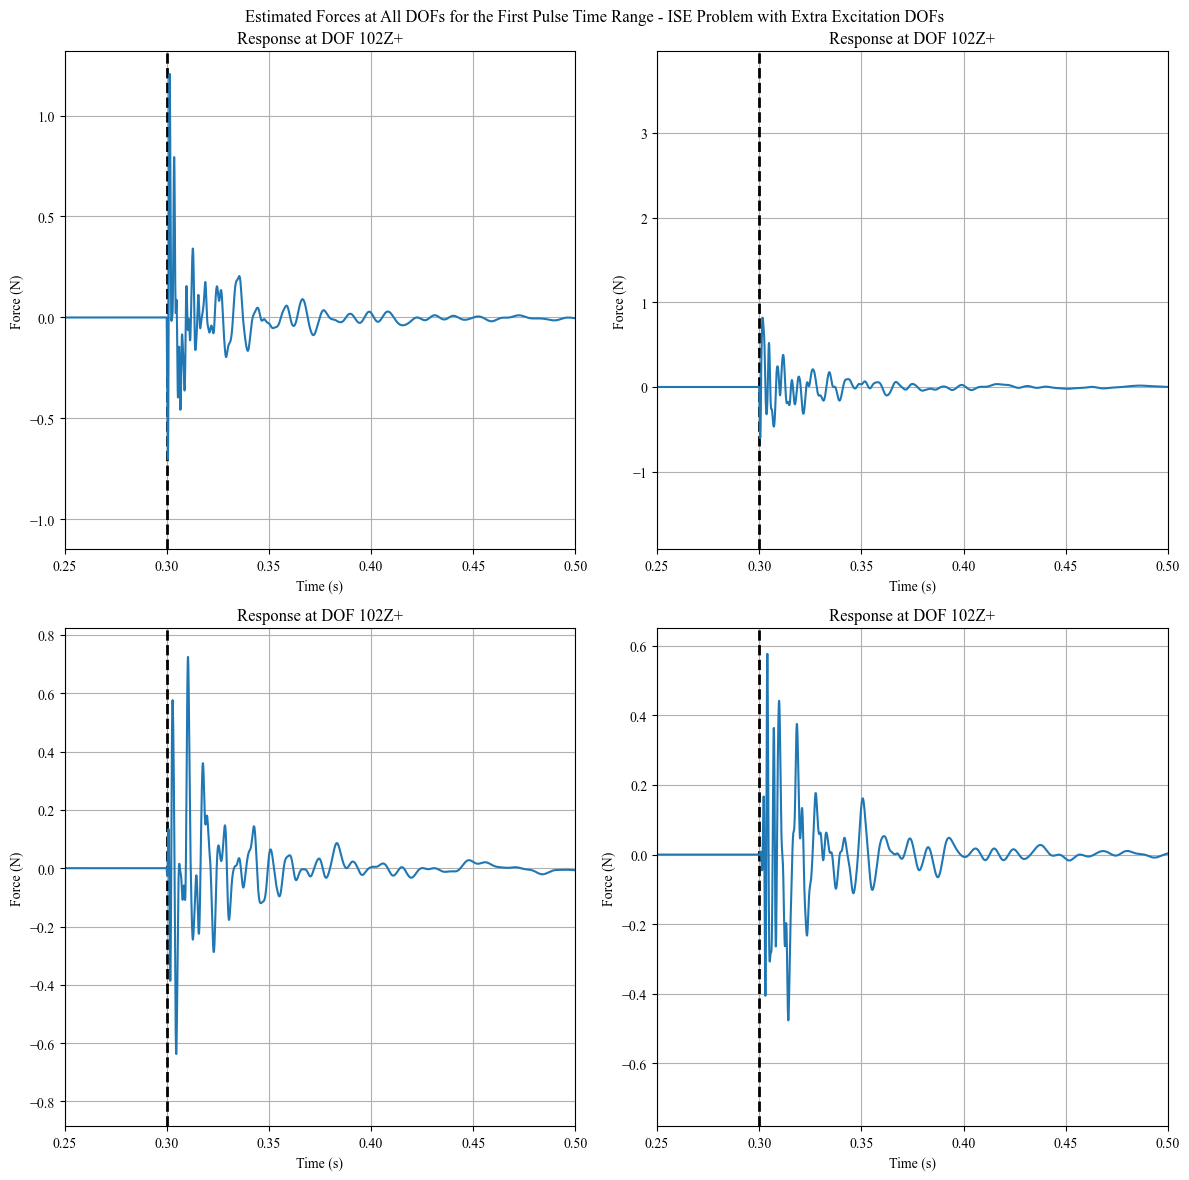

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(12,12))

for ii in range(2):
    for jj in range(2): 
        ax[ii,jj].axvline(truth_response[ii*2+jj].abscissa[3000], color='k', linestyle='--', 
                          linewidth=2)
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, padded_response[ii*2+jj].ordinate)
        ax[ii,jj].grid(); ax[ii,jj].set_xlim(left=0.25, right=0.5)
        ax[ii,jj].set_xlabel('Time (s)'); ax[ii,jj].set_ylabel('Force (N)')
        ax[ii,jj].set_title('Force at DOF {:}'.format(reference_coordinate_1[ii*2+jj].string_array()))

fig.suptitle('Estimated Forces at All DOFs for the First Pulse Time Range - ISE Problem with Extra Excitation DOFs')
fig.tight_layout()

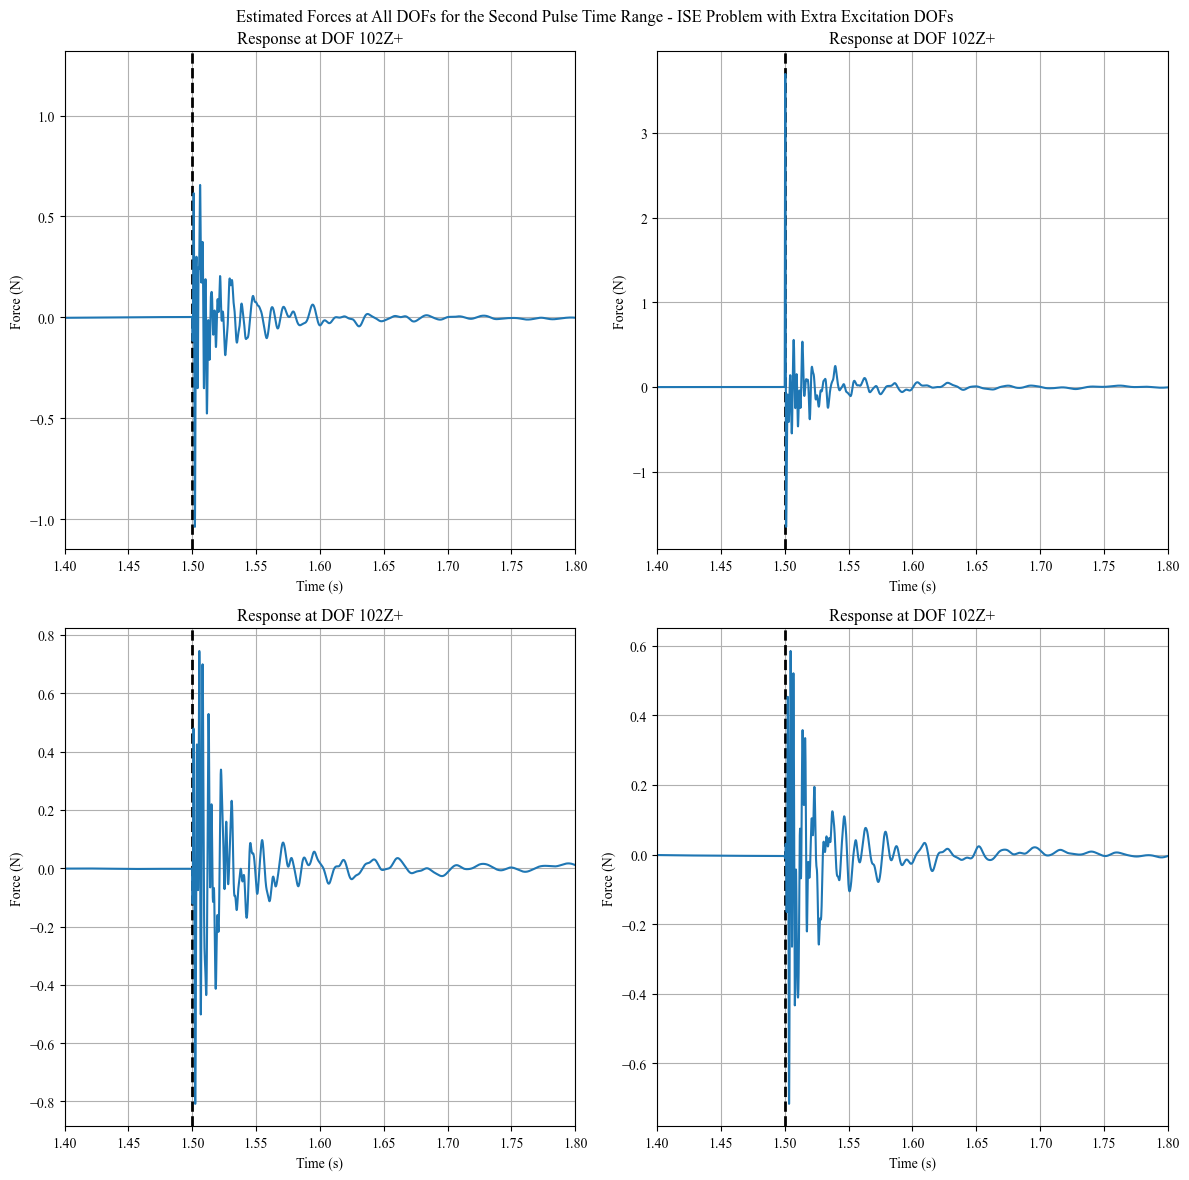

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(12,12))

for ii in range(2):
    for jj in range(2): 
        ax[ii,jj].axvline(truth_response[ii*2+jj].abscissa[15000], color='k', linestyle='--', 
                          linewidth=2)
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, padded_response[ii*2+jj].ordinate)
        ax[ii,jj].grid(); ax[ii,jj].set_xlim(left=1.4, right=1.8)
        ax[ii,jj].set_xlabel('Time (s)'); ax[ii,jj].set_ylabel('Force (N)')
        ax[ii,jj].set_title('Response at DOF {:}'.format(reference_coordinate_1[ii*2+jj].string_array()))

fig.suptitle('Estimated Forces at All DOFs for the Second Pulse Time Range - ISE Problem with Extra Excitation DOFs')
fig.tight_layout()

Also as expected, the ISE problem set-up with extra force DOFs reconstructs responses with extremely high accuracy. This accuracy shown in the plots below that compare the truth and reconstructed responses, which are zoomed into the time ranges for the truth pulses.  

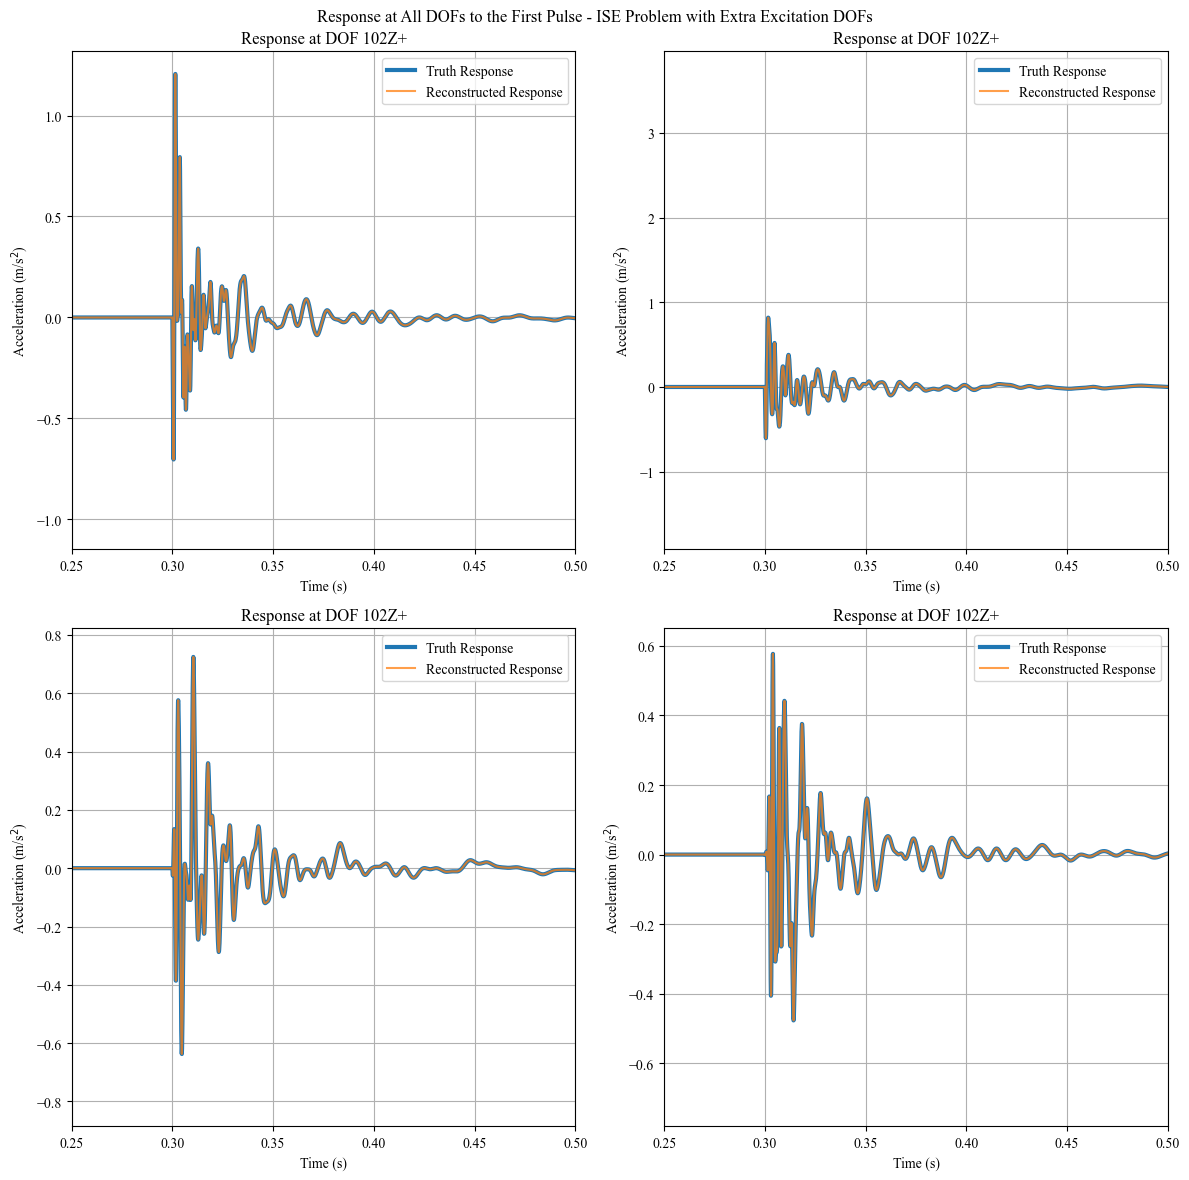

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(12,12))

for ii in range(2):
    for jj in range(2): 
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, padded_response[ii*2+jj].ordinate, 
                       label='Truth Response', linewidth=3)
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, reconstructed_response_response_perturbed_time_1[:,ii*2+jj,0],
                    label='Reconstructed Response', alpha=0.75)
        ax[ii,jj].grid(); ax[ii,jj].legend(); ax[ii,jj].set_xlim(left=0.25, right=0.5)
        ax[ii,jj].set_xlabel('Time (s)'); ax[ii,jj].set_ylabel('Acceleration (m/s$^2$)')
        ax[ii,jj].set_title('Response at DOF {:}'.format(padded_response[ii*2+jj].response_coordinate.string_array()))

fig.suptitle('Response at All DOFs to the First Pulse - ISE Problem with Extra Excitation DOFs')
fig.tight_layout()

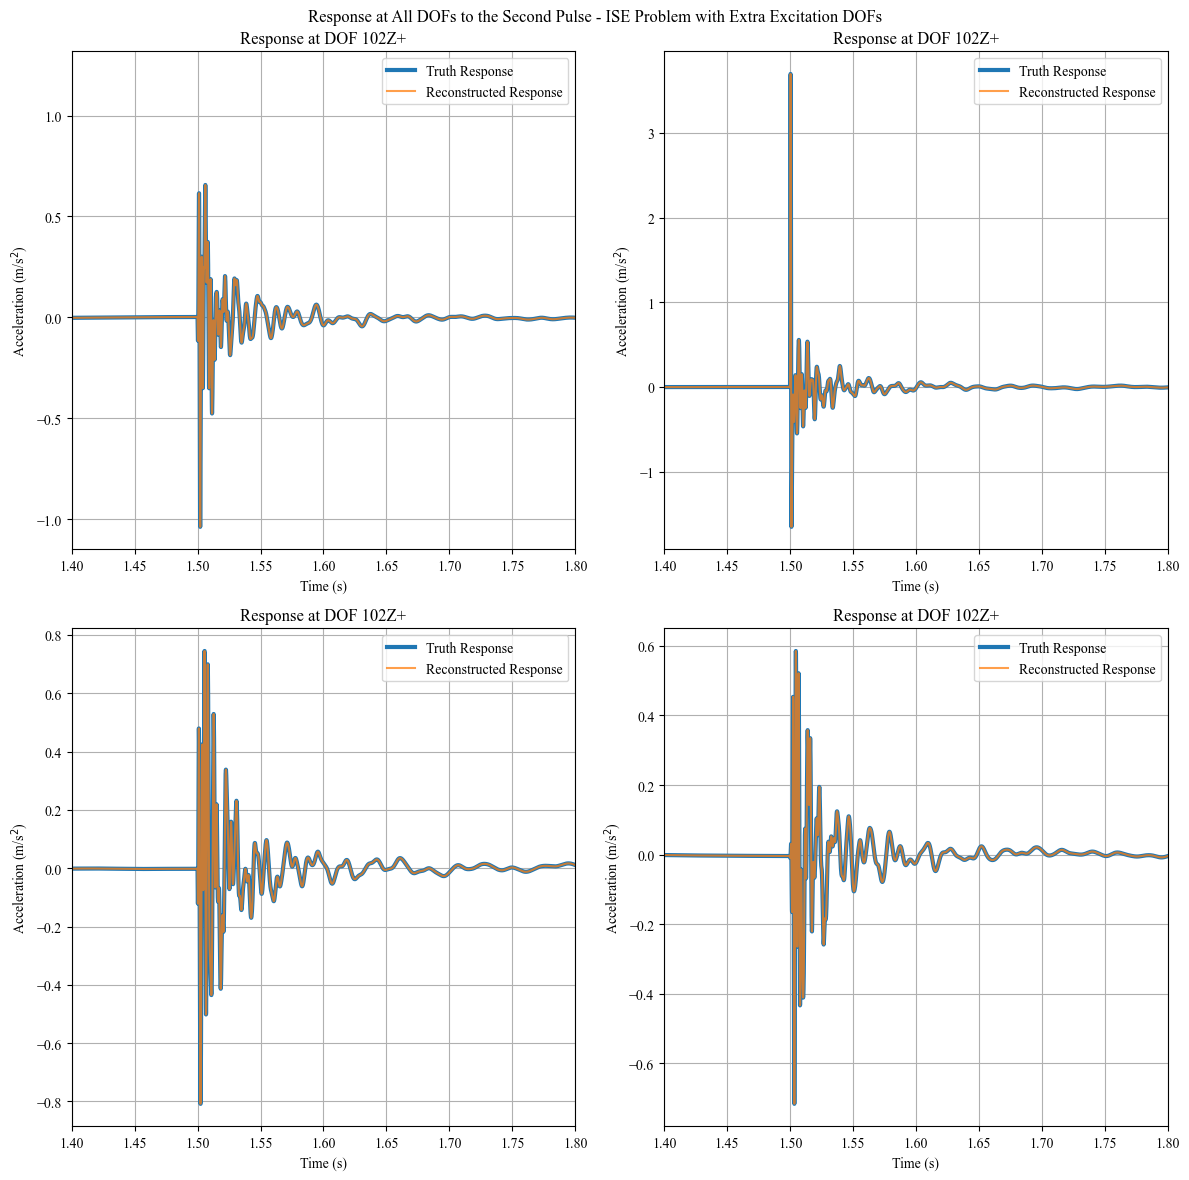

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(12,12))

for ii in range(2):
    for jj in range(2): 
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, padded_response[ii*2+jj].ordinate, 
                       label='Truth Response', linewidth=3)
        ax[ii,jj].plot(padded_response[ii*2+jj].abscissa, reconstructed_response_response_perturbed_time_1[:,ii*2+jj,0],
                       label='Reconstructed Response', alpha=0.75)
        ax[ii,jj].grid(); ax[ii,jj].legend(); ax[ii,jj].set_xlim(left=1.4, right=1.8)
        ax[ii,jj].set_xlabel('Time (s)'); ax[ii,jj].set_ylabel('Acceleration (m/s$^2$)')
        ax[ii,jj].set_title('Response at DOF {:}'.format(padded_response[ii*2+jj].response_coordinate.string_array()))

fig.suptitle('Response at All DOFs to the Second Pulse - ISE Problem with Extra Excitation DOFs')
fig.tight_layout()